In [1]:
# BAN 668: Mid-Project Report - Data Preparation & EDA
# Name: [Newton Mwirebua]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [4]:
# LOAD DATA
df = pd.read_csv('Job_Placement_Data_Enhanced.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 215 non-null    object 
 1   ssc_percentage         215 non-null    float64
 2   ssc_board              215 non-null    object 
 3   hsc_percentage         215 non-null    float64
 4   hsc_board              215 non-null    object 
 5   hsc_subject            215 non-null    object 
 6   degree_percentage      215 non-null    float64
 7   undergrad_degree       215 non-null    object 
 8   work_experience        215 non-null    object 
 9   emp_test_percentage    215 non-null    float64
 10  specialisation         215 non-null    object 
 11  mba_percent            215 non-null    float64
 12  status                 215 non-null    object 
 13  years_experience       215 non-null    int64  
 14  skills_match_percent   215 non-null    int64  
 15  num_ce

In [6]:
df.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score,company_tier,job_competition_level
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,3,98,1,0,94,Mid,Medium
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,4,88,1,1,54,MNC,Low
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,2,41,1,1,82,Startup,Low
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,4,41,0,0,50,MNC,High
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,4,67,0,0,67,Mid,High


In [7]:
df.describe()

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,2.483721,70.413953,2.423256,0.483721,74.046512
std,10.827205,10.897509,7.358743,13.275956,5.833385,1.701694,17.235065,1.708259,0.500901,14.602447
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000,40.000000,0.000000,0.000000,50.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,1.000000,58.000000,1.000000,0.000000,62.500000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,3.000000,71.000000,3.000000,0.000000,74.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,4.000000,86.000000,4.000000,1.000000,86.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,5.000000,99.000000,5.000000,1.000000,99.000000


In [8]:
# check for missing values.
df.isnull().sum()

gender                   0
ssc_percentage           0
ssc_board                0
hsc_percentage           0
hsc_board                0
hsc_subject              0
degree_percentage        0
undergrad_degree         0
work_experience          0
emp_test_percentage      0
specialisation           0
mba_percent              0
status                   0
years_experience         0
skills_match_percent     0
num_certifications       0
internship_completed     0
interview_score          0
company_tier             0
job_competition_level    0
dtype: int64

In [9]:
# DATA CLEANING & PREPARATION
# we will remove 'company_tier' and 'job_competition_level' 
# to prevent target leakage (these are determined AFTER placement).
cols_to_drop = ['company_tier', 'job_competition_level']
df_clean = df.drop(columns=cols_to_drop)

In [10]:
df_clean.columns

Index(['gender', 'ssc_percentage', 'ssc_board', 'hsc_percentage', 'hsc_board',
       'hsc_subject', 'degree_percentage', 'undergrad_degree',
       'work_experience', 'emp_test_percentage', 'specialisation',
       'mba_percent', 'status', 'years_experience', 'skills_match_percent',
       'num_certifications', 'internship_completed', 'interview_score'],
      dtype='object')

In [11]:
# SUMMARY STATISTICS
# Displaying numerical statistics
df_clean.describe()

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,2.483721,70.413953,2.423256,0.483721,74.046512
std,10.827205,10.897509,7.358743,13.275956,5.833385,1.701694,17.235065,1.708259,0.500901,14.602447
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000,40.000000,0.000000,0.000000,50.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,1.000000,58.000000,1.000000,0.000000,62.500000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,3.000000,71.000000,3.000000,0.000000,74.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,4.000000,86.000000,4.000000,1.000000,86.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,5.000000,99.000000,5.000000,1.000000,99.000000


In [12]:
# EXPLORATORY DATA ANALYSIS (EDA)

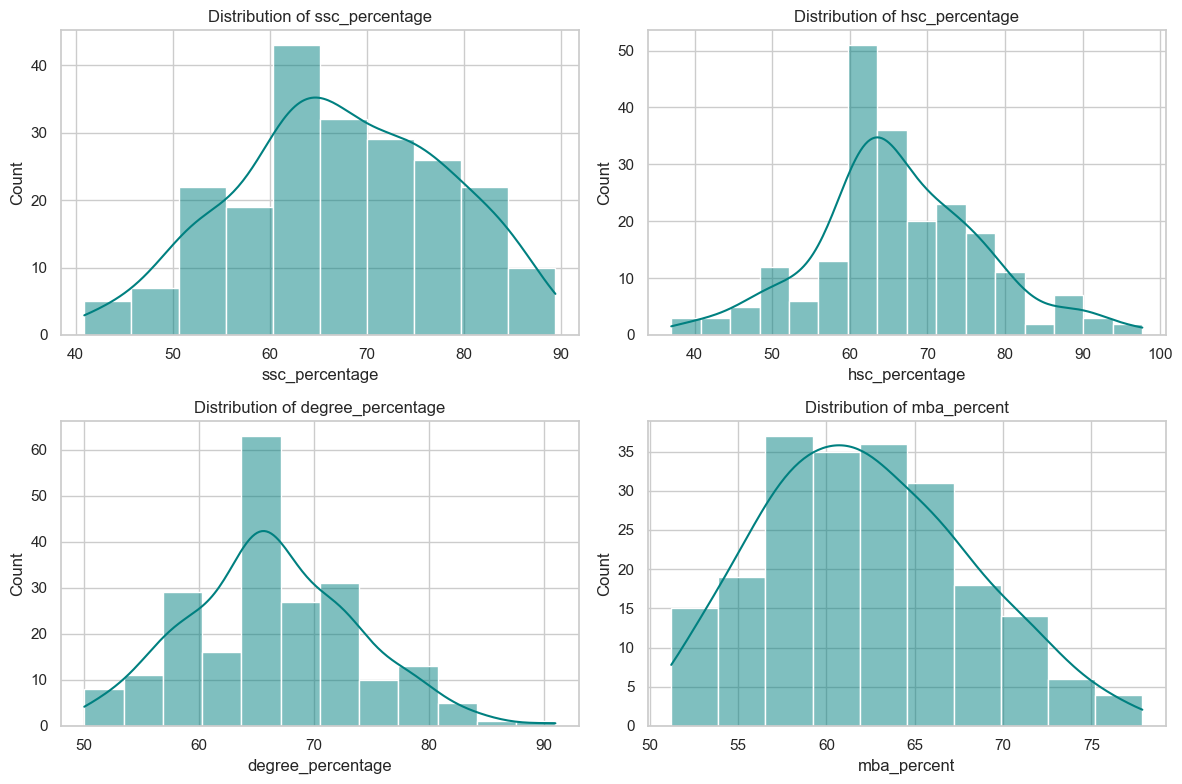

In [13]:
# Numerical Variables - Academic Distribution
# Visualizing the distribution of academic scores across different levels
academic_scores = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'mba_percent']
plt.figure(figsize=(12, 8))
for i, col in enumerate(academic_scores, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [14]:
# Categorical Variables - Placement & Experience

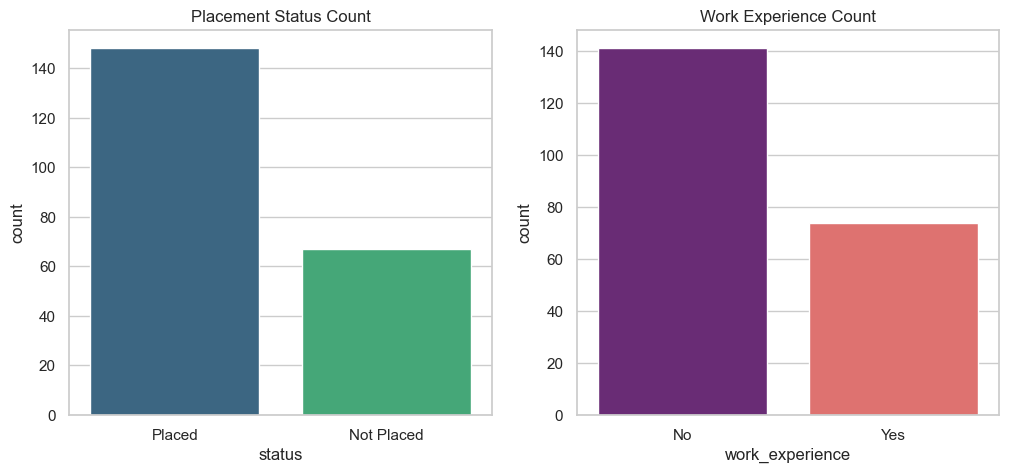

In [15]:
# Visualizing the target variable and key categorical features
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='status', palette='viridis')
plt.title('Placement Status Count')

plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='work_experience', palette='magma')
plt.title('Work Experience Count')
plt.show()

In [16]:
# Relationship Exploration - Academic Performance vs. Placement

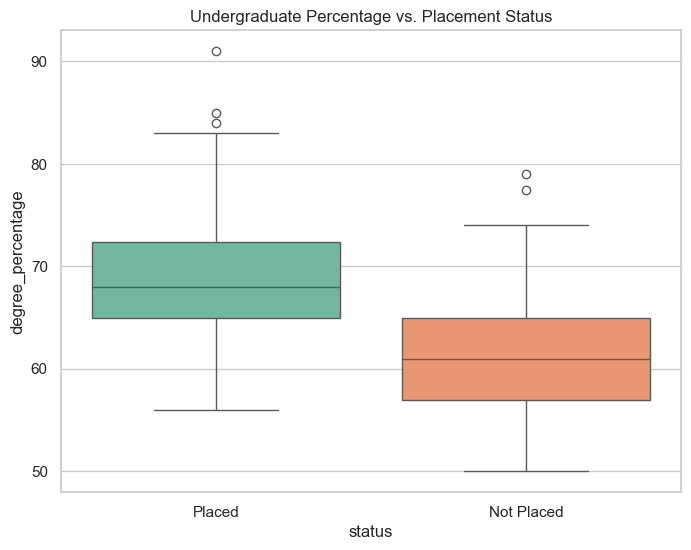

In [17]:
# Comparing degree percentages between placed and unplaced students
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='status', y='degree_percentage', palette='Set2')
plt.title('Undergraduate Percentage vs. Placement Status')
plt.show()

In [18]:
# Relationship Exploration - Correlation Heatmap

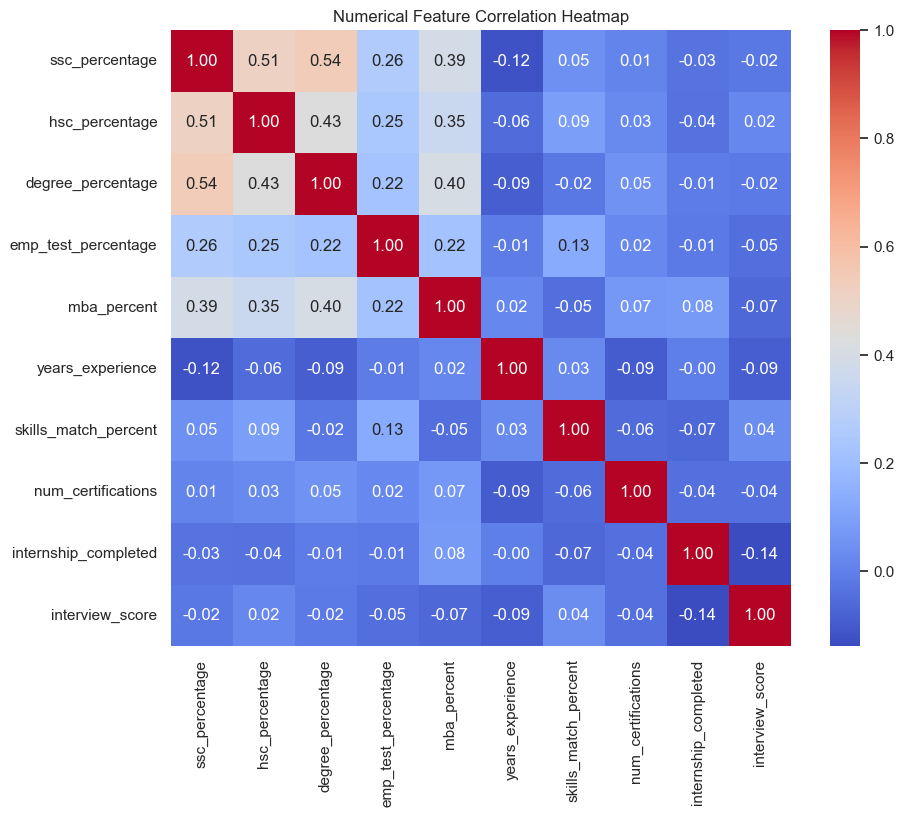

In [19]:
# Identifying linear relationships between all numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

In [20]:
# Data Mutation
# Data Mutation - use df_clean, not df!
df_clean['AcademicLevel'] = pd.cut(df_clean['mba_percent'],
                                    bins=[0, 60, 70, 100],
                                    labels=['Low', 'Medium', 'High'])
df_clean = df_clean.drop(columns=['mba_percent'])

df_clean['AcademicScore'] = (df_clean['ssc_percentage'] + df_clean['hsc_percentage'] + df_clean['degree_percentage']) / 3
df_clean = df_clean.drop(columns=['ssc_percentage', 'hsc_percentage', 'degree_percentage'])

df_clean.head(5)

,gender,ssc_board,hsc_board,hsc_subject,undergrad_degree,work_experience,emp_test_percentage,specialisation,status,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score,AcademicLevel,AcademicScore
0,M,Others,Others,Commerce,Sci&Tech,No,55.0,Mkt&HR,Placed,3,98,1,0,94,Low,72.000000
1,M,Central,Others,Science,Sci&Tech,Yes,86.5,Mkt&Fin,Placed,4,88,1,1,54,Medium,78.380000
2,M,Central,Central,Arts,Comm&Mgmt,No,75.0,Mkt&Fin,Placed,2,41,1,1,82,Low,65.666667
3,M,Central,Central,Science,Sci&Tech,No,66.0,Mkt&HR,Not Placed,4,41,0,0,50,Low,53.333333
4,M,Central,Central,Commerce,Comm&Mgmt,No,96.8,Mkt&Fin,Placed,4,67,0,0,67,Low,77.566667


In [21]:
df.dtypes

gender                    object
ssc_percentage           float64
ssc_board                 object
hsc_percentage           float64
hsc_board                 object
hsc_subject               object
degree_percentage        float64
undergrad_degree          object
work_experience           object
emp_test_percentage      float64
specialisation            object
mba_percent              float64
status                    object
years_experience           int64
skills_match_percent       int64
num_certifications         int64
internship_completed       int64
interview_score            int64
company_tier              object
job_competition_level     object
dtype: object

In [22]:
# Data Type Conversions
# Converting categorical columns to the pandas `category` dtype, with `AcademicLevel` made an ordered category (Low < Medium < High).

In [23]:
# Data Type Conversions
df_clean['status']           = df_clean['status'].astype('category')
df_clean['gender']           = df_clean['gender'].astype('category')
df_clean['work_experience']  = df_clean['work_experience'].astype('category')
df_clean['hsc_subject']      = df_clean['hsc_subject'].astype('category')
df_clean['undergrad_degree'] = df_clean['undergrad_degree'].astype('category')
df_clean['specialisation']   = df_clean['specialisation'].astype('category')

df_clean['AcademicLevel'] = pd.Categorical(
    df_clean['AcademicLevel'], categories=['Low', 'Medium', 'High'], ordered=True
)

df_clean.dtypes

gender                  category
ssc_board                 object
hsc_board                 object
hsc_subject             category
undergrad_degree        category
work_experience         category
emp_test_percentage      float64
specialisation          category
status                  category
years_experience           int64
skills_match_percent       int64
num_certifications         int64
internship_completed       int64
interview_score            int64
AcademicLevel           category
AcademicScore            float64
dtype: object

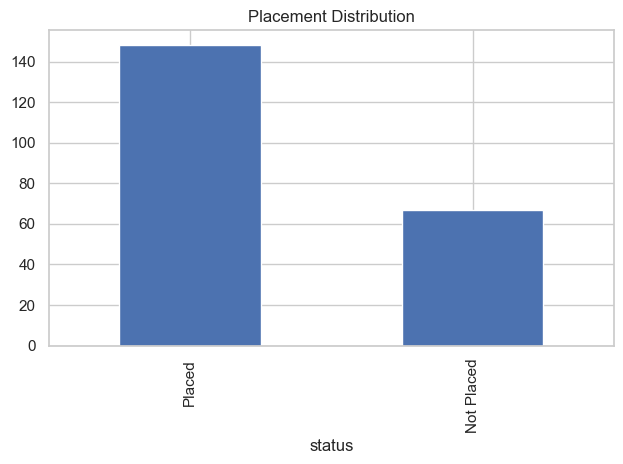

In [24]:
# EDA
df_clean['status'].value_counts().plot(kind='bar', title='Placement Distribution')
plt.tight_layout()
plt.show()

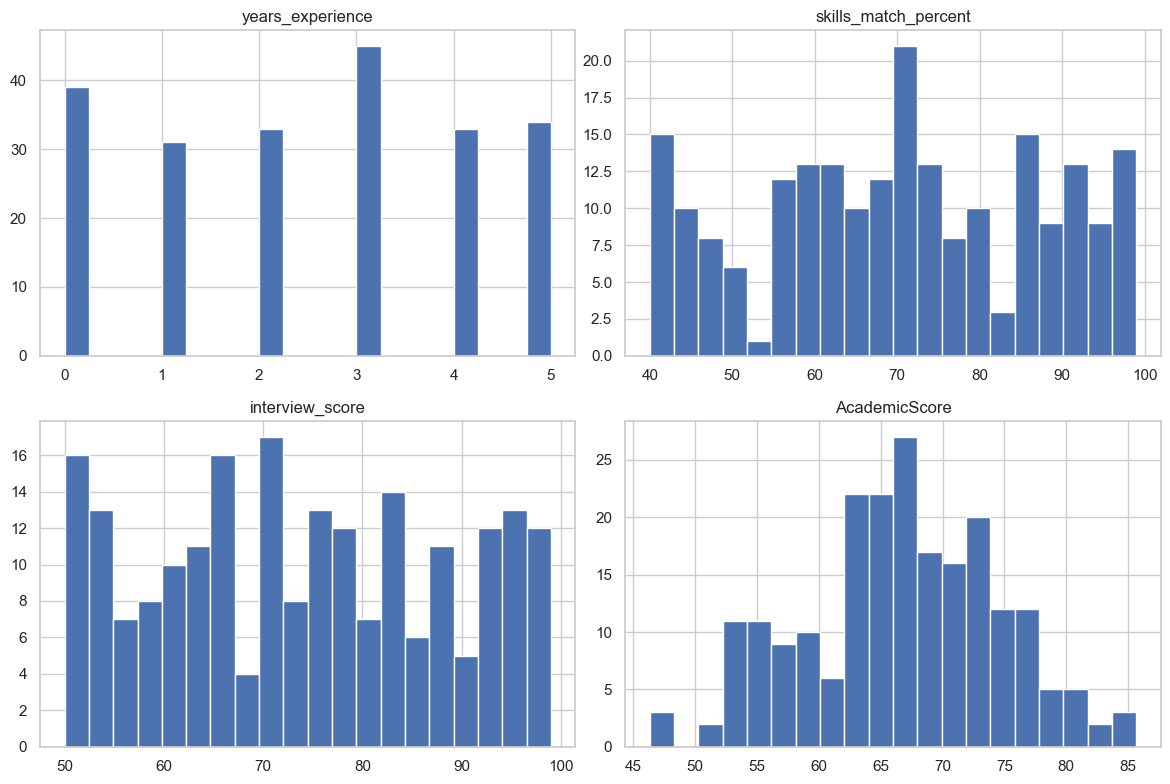

In [25]:
# Numeric columns: histograms
num_cols = ['years_experience', 'skills_match_percent',
            'interview_score', 'AcademicScore']
df_clean[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

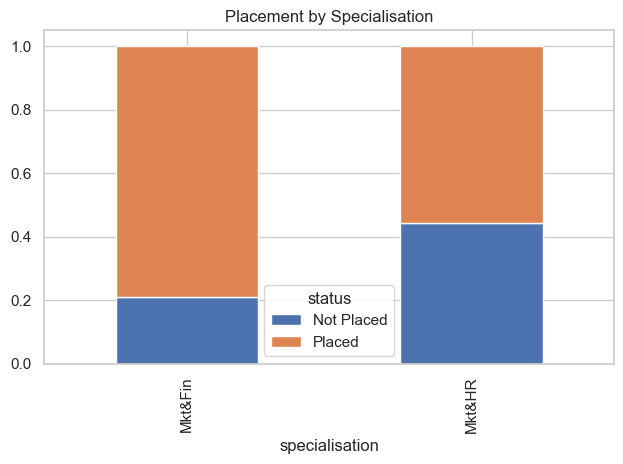

In [26]:
# Placement rate by Specialisation
pd.crosstab(df_clean['specialisation'], df_clean['status'], normalize='index').plot(
    kind='bar', stacked=True, title='Placement by Specialisation')
plt.tight_layout()
plt.show()

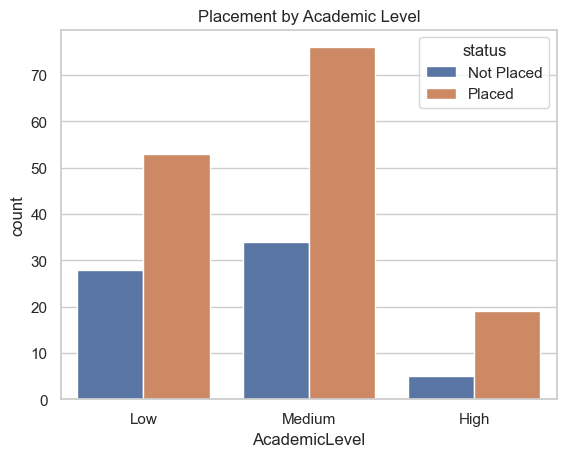

In [27]:
# AcademicLevel vs Placement Status
sns.countplot(data=df_clean, x='AcademicLevel', hue='status')
plt.title('Placement by Academic Level')
plt.show()

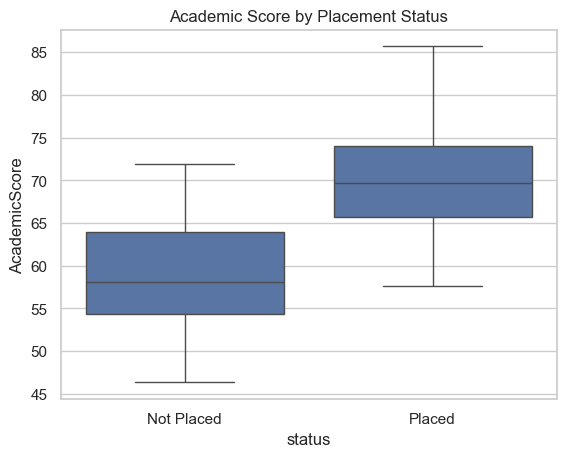

In [28]:
sns.boxplot(data=df_clean, x='status', y='AcademicScore')
plt.title('Academic Score by Placement Status')
plt.show()

In [29]:
# Preparing Predictors and Target

In [30]:
# Preparing Predictors and Target
# check target variable
status_pct = round(df_clean['status'].value_counts(normalize=True) * 100, 2)

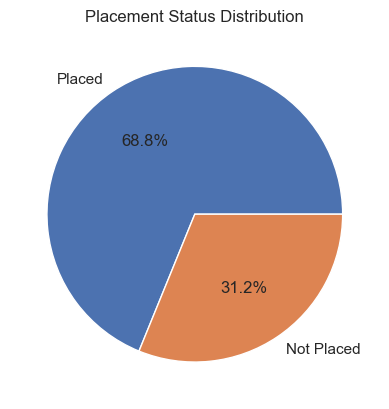

In [31]:
# target — pie chart (checking imbalance)
plt.pie(status_pct, labels=status_pct.index, autopct='%1.1f%%')
plt.title('Placement Status Distribution')
plt.show()

In [32]:
# Create y as the target variable
y = df_clean['status'].map({'Placed': 1, 'Not Placed': 0})

In [33]:
# Create X by dropping the target variable
X = df_clean.drop(columns=['status'])

In [34]:
# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

# Check info of X
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   emp_test_percentage        215 non-null    float64
 1   years_experience           215 non-null    int64  
 2   skills_match_percent       215 non-null    int64  
 3   num_certifications         215 non-null    int64  
 4   internship_completed       215 non-null    int64  
 5   interview_score            215 non-null    int64  
 6   AcademicScore              215 non-null    float64
 7   gender_M                   215 non-null    bool   
 8   ssc_board_Others           215 non-null    bool   
 9   hsc_board_Others           215 non-null    bool   
 10  hsc_subject_Commerce       215 non-null    bool   
 11  hsc_subject_Science        215 non-null    bool   
 12  undergrad_degree_Others    215 non-null    bool   
 13  undergrad_degree_Sci&Tech  215 non-null    bool   

In [35]:
X.head(5)

,emp_test_percentage,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score,AcademicScore,gender_M,ssc_board_Others,hsc_board_Others,hsc_subject_Commerce,hsc_subject_Science,undergrad_degree_Others,undergrad_degree_Sci&Tech,work_experience_Yes,specialisation_Mkt&HR,AcademicLevel_Medium,AcademicLevel_High
0,55.0,3,98,1,0,94,72.000000,True,True,True,True,False,False,True,False,True,False,False
1,86.5,4,88,1,1,54,78.380000,True,False,True,False,True,False,True,True,False,True,False
2,75.0,2,41,1,1,82,65.666667,True,False,False,False,False,False,False,False,False,False,False
3,66.0,4,41,0,0,50,53.333333,True,False,False,False,True,False,True,False,True,False,False
4,96.8,4,67,0,0,67,77.566667,True,False,False,True,False,False,False,False,False,False,False


In [36]:
# Splitting the Data

In [37]:
# Import train-test split
from sklearn.model_selection import train_test_split

In [38]:
# Split the data into training and testing sets
# test_size=0.20 means 20% goes to the test set
# random_state=42 helps make results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
# Check the shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((172, 18), (43, 18), (172,), (43,))

In [40]:
# Apply StandardScaler

In [41]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [42]:
# Create the scaler
sc = StandardScaler()

In [43]:
# Fit the scaler on the training data and transform it
X_train = sc.fit_transform(X_train)

In [44]:
# Transform the testing data using the SAME fitted scaler (no re-fit!)
X_test = sc.transform(X_test)

In [45]:
# Train the Classification Models

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [47]:
pred_logr = lr.predict(X_test)

In [48]:
# Train Decision Tree

In [49]:
# Create the decision tree model, random_state=42
dtc = DecisionTreeClassifier(random_state=42)

# Fit the model on the scaled training data
# Note: scaling is not required for trees, but using scaled data here is okay
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [50]:
# Generate predictions
pred_dtc = dtc.predict(X_test)

In [51]:
# Train KNN

In [52]:
# Create a KNeighborsClassifier with n_neighbors=5
knc = KNeighborsClassifier()
knc.fit(X_train, y_train)

KNeighborsClassifier()

In [53]:
# Evaluate Model F1 Score

In [54]:
# Re-generate all three predictions
pred_logr = lr.predict(X_test)
pred_dtc  = dtc.predict(X_test)
pred_knc  = knc.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
f1_logr = accuracy_score(y_test, pred_logr)
f1_dtc  = accuracy_score(y_test, pred_dtc)
f1_knc  = accuracy_score(y_test, pred_knc)

In [56]:
# MODEL COMPARISON
# Create DataFrame
f1_df = pd.DataFrame({'model': ['Logistic Regression', 'Decision Tree', 'KNN'],
                      'f1':    [f1_logr, f1_dtc, f1_knc]})

# Sort from highest to lowest score
f1_df = f1_df.sort_values(by='f1', ascending=False)

# Display result
f1_df

,model,f1
0,Logistic Regression,0.883721
1,Decision Tree,0.767442
2,KNN,0.720930


In [57]:
# Confusion Matrix and Classification Report

In [58]:
confusion_mat = confusion_matrix(y_test, pred_logr)
confusion_mat

array([[11,  2],
       [ 3, 27]])

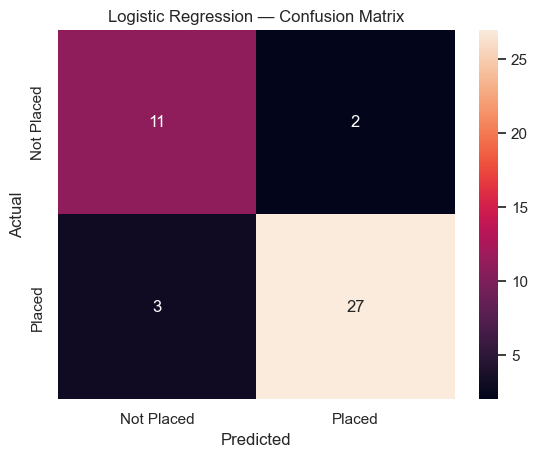

In [59]:
sns.heatmap(confusion_mat, annot=True, fmt='g',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [60]:
print(classification_report(y_test, pred_logr,
                            target_names=['Not Placed', 'Placed']))

              precision    recall  f1-score   support

  Not Placed       0.79      0.85      0.81        13
      Placed       0.93      0.90      0.92        30

    accuracy                           0.88        43
   macro avg       0.86      0.87      0.87        43
weighted avg       0.89      0.88      0.88        43



In [61]:
print(classification_report(y_test, pred_dtc,
                            target_names=['Not Placed', 'Placed']))

              precision    recall  f1-score   support

  Not Placed       0.59      0.77      0.67        13
      Placed       0.88      0.77      0.82        30

    accuracy                           0.77        43
   macro avg       0.74      0.77      0.74        43
weighted avg       0.80      0.77      0.77        43



In [62]:
print(classification_report(y_test, pred_knc,
                            target_names=['Not Placed', 'Placed']))

              precision    recall  f1-score   support

  Not Placed       0.55      0.46      0.50        13
      Placed       0.78      0.83      0.81        30

    accuracy                           0.72        43
   macro avg       0.66      0.65      0.65        43
weighted avg       0.71      0.72      0.71        43



In [63]:
# Hyperparameter Tuning (Logistic Regression)
# Logistic Regression had the strongest baseline accuracy, so we tune it with `GridSearchCV` using 5-fold cross-validation. The `class_weight='balanced'` option is included to address the class imbalance between Placed and Not Placed students.

In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced'],
}

In [65]:
#1 Run the Grid Search
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid,
                    cv=5, scoring='f1')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

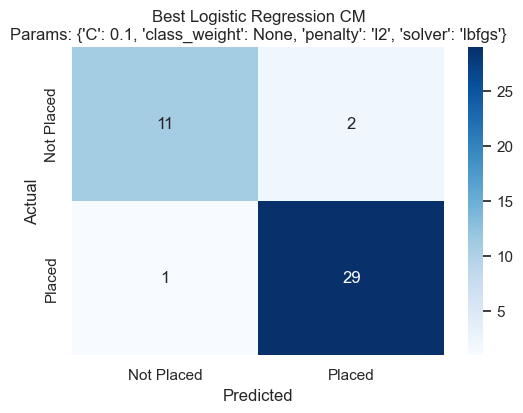

              precision    recall  f1-score   support

  Not Placed       0.92      0.85      0.88        13
      Placed       0.94      0.97      0.95        30

    accuracy                           0.93        43
   macro avg       0.93      0.91      0.92        43
weighted avg       0.93      0.93      0.93        43



In [66]:
# 2. Use the BEST model to make predictions
best_logr = grid.best_estimator_
y_pred = best_logr.predict(X_test)

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Best Logistic Regression CM\nParams: {grid.best_params_}')
plt.show()

# 5. Print the report to see the new Recall score
print(classification_report(y_test, y_pred,
                            target_names=['Not Placed', 'Placed']))

In [67]:
# Save the Final Model

In [68]:
import joblib

# 'best_logr' is the model we tuned earlier
joblib.dump(best_logr, 'placement_model.pkl')

# Save the Scaler too so future predictions use the same scaling
joblib.dump(sc, 'placement_scaler.pkl')

['placement_scaler.pkl']